# Data 6550: Reproducibility in Data Science : A Data Ethic Project
## Wine feature importance and quality prediction: A comparative study of machine learning algorithms with unbalanced data
- Siphendulwe Zaza1zazasiphendulwe@gmail.com 
- Marcellin Atemkeng1∗m.atemkeng@ru.ac.za Sisipho 
- Hamlomo1,2s.hamlomo@ru.ac.za

Citation
- Zaza, S., Marcellin Atemkeng, & Sisipho Hamlomo. (2023). Wine feature importance and quality prediction: A comparative study of
  machine learning algorithms with unbalanced data. ArXiv (Cornell University). https://doi.org/10.48550/arxiv.2310.01584



### Group 5

#### ReadMe
- This notebook created by Alexander Price for Data6550 Ethics at MTSU. 
- In this notebook use of AI was used to debug, get suggestiosn, and help make some code blocks. Claude AI and Githup Copliot were used.
- A lot of this code is from resued homework done by myself in other classes at MTSU.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
red_wine_raw = pd.read_csv("D:\\Data Ethics\\Ethics Group 5 Project 5 Wine\\winequality-red.csv",header=0, sep=";")

In [4]:
red_wine_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
red_wine_raw['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

## Pre Processing 

In [6]:
red_wine = red_wine_raw.copy()

In [7]:
red_wine['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

### Excluding duplicate entries and data points with missing values from all wine category dataframes

In [8]:
red_wine.duplicated().sum()

240

In [9]:
red_wine.drop_duplicates(inplace=True)

In [10]:
red_wine.dropna(inplace=True)

In [11]:
red_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 138.0 KB


In [12]:
red_wine['quality'].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

- After dropping duplicates and missing values new values in each dataframe are 
    - quality of 5: went from 681 to 577 dropping a total of 104 duplicates and no values
    - quality of 6 : went from 638 to 535 dropping a total of 103 duplicates and no values
    - quality of 7 : went from 199 to 167 dropping a total of 32 duplicates and no values
    - quality of 4 : none was dropped
    - quality of 8 : none was dropped
    - quality of 3 : none was dropped

#### Encoding Quality 
- bad wine is quality less than 5
- normal wine is quality between 5 and 6 
- good wine is quality between 7 and 10

- so for encoding:
    - 0 = bad wine
    - 1 = normal wine
    - 2 = good wine

In [13]:
def encode_quality(quality):
    if quality < 5:
        return 0  # bad wine
    elif 5 <= quality <= 6:
        return 1  # normal wine
    elif 7 <= quality <= 10:
        return 2  # good wine
    else:
        return np.nan

red_wine_encoded = red_wine['quality'].apply(encode_quality)

In [14]:
red_wine_processed = red_wine.copy()
red_wine_processed['quality'] = red_wine_encoded

In [15]:
red_wine_processed['quality'].sample(10)

1076    1
710     1
78      1
413     2
90      1
1474    1
1023    1
876     0
610     1
1431    1
Name: quality, dtype: int64

In [16]:
red_wine_processed['quality'].value_counts()

quality
1    1112
2     184
0      63
Name: count, dtype: int64

### This is such a small dataset there is a notion that the modeling will overfit the data. 

## Analysis of the data before and after preprocessing

#### Summary of the data after processing but before encoding

In [17]:
red_wine_summary = red_wine.describe().transpose()[['mean', 'std', 'min', 'max', '50%']].rename(
    columns={'mean': 'Mean', 'std': 'Sd','min': 'Min','max': 'Max','50%': 'Median'})
red_wine_summary.index = [name.capitalize() for name in red_wine_summary.index]
red_wine_summary.index.name = 'Variable Name'

display_summary = red_wine_summary.copy()
display_summary = display_summary.apply(lambda column: column.map(lambda value: f'{value:.2f}'))

if 'Density' in display_summary.index:
    display_summary.loc['Density'] = red_wine_summary.loc['Density'].map(lambda value: f'{value:.4f}')

display(
    display_summary.style.set_properties(**{'font-size': '16px'}).set_table_styles([
        {'selector': 'th', 'props': [('font-size', '16px')]},
        {'selector': 'td', 'props': [('font-size', '16px')]}])
)


,Mean,Sd,Min,Max,Median
Variable Name,,,,,
Fixed acidity,8.31,1.74,4.60,15.90,7.90
Volatile acidity,0.53,0.18,0.12,1.58,0.52
Citric acid,0.27,0.20,0.00,1.00,0.26
Residual sugar,2.52,1.35,0.90,15.50,2.20
Chlorides,0.09,0.05,0.01,0.61,0.08
Free sulfur dioxide,15.89,10.45,1.00,72.00,14.00
Total sulfur dioxide,46.83,33.41,6.00,289.00,38.00
Density,0.9967,0.0019,0.9901,1.0037,0.9967
Ph,3.31,0.16,2.74,4.01,3.31


- in this summary for the data it is almost the same as the summary the paper got but there are differences noticed:
    - Fixed Acidity standard deviation is 0.1 off
    - Volatile acidity the mean is off by 0.1
    - Citric acid the standard deviation is off by 0.1
    - Residual sugar is correct after pre processing the data
    - Chlorides the the Mean, standard deviation and the Median are all off by 0.1
    - Free Sulfur Dioxide the standard deviation is off by 0.1
    - Total Sulfur Dioxide the mean and standard deviation is off by 0.1
    - Density is all over the place I gave it four decimal places to show they didn't round for this summary which in my opinion should have, comparing to the paper the mean, standard deviation, minimum, and median should have all rounded up to a whole number or for standard deviation 0.002
    - PH mean and standard deviation is off by 0.1
    - Sulphates only the mean is off by 0.1
    - Alcohol is correct 
    - Quality is correct

- So out of all the features only 3 were matching to the paper the others were at least off by 0.1 and this might be due if they rounded that one statistic or not. This however this analysis and modeling is going to not have the same numbers when even the summary is not correct with the paper. 

### Correlation Matrix

- So they used the entire dataset for this correlation matrix and the paper does not specify that they did this before or after preprocessing. So to see the differences I did a a correlation with the raw data and then make another after the preprocessing, the one in the paper is one that is done before pre processing and matches exactly.

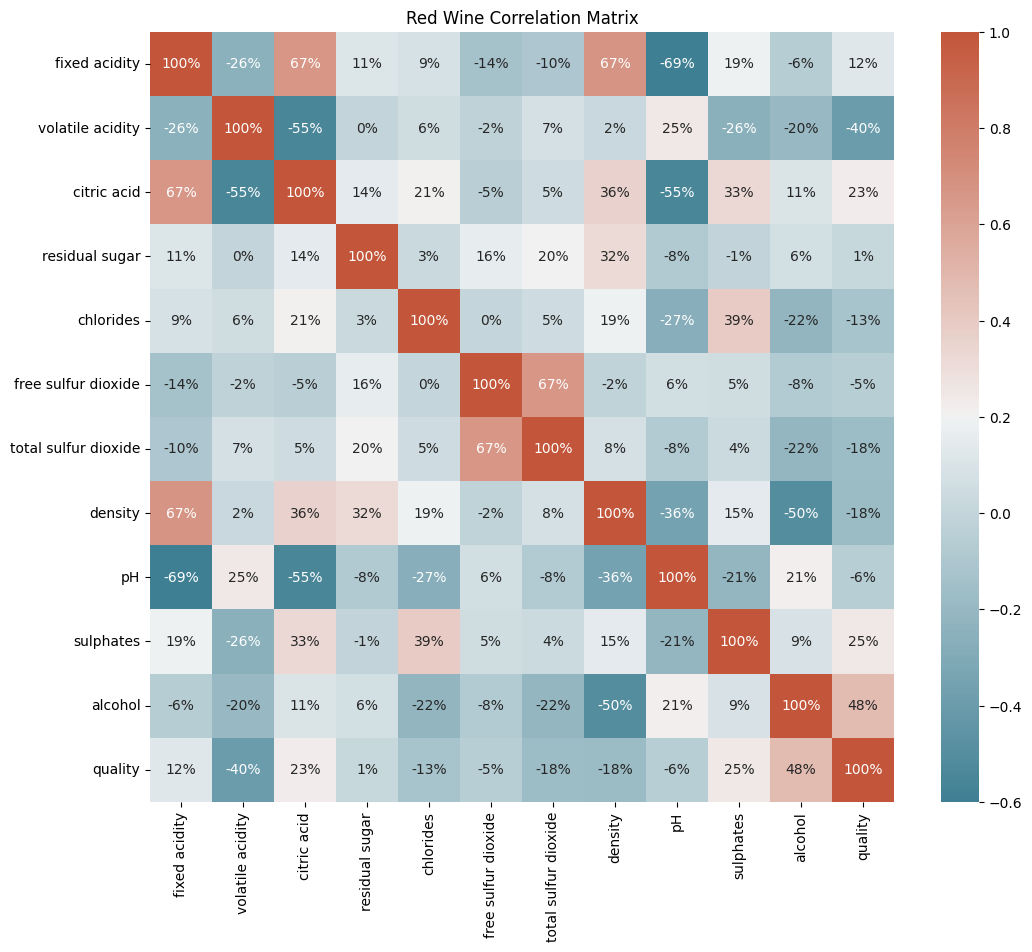

In [18]:
# Before preprocessing just doing a initial data exploration 
correlation_matrix = red_wine.corr()
percent_labels = correlation_matrix.multiply(100).round().astype(int).astype(str) + '%' # To match the paper's correlation matrix with percentage labels
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=percent_labels, fmt='',
            cmap= sns.diverging_palette(220, 20, as_cmap=True), vmin=-0.6, vmax=1) # Adjusted vmin and vmax for better color contrast and readability to reproduce the paper
plt.title('Red Wine Correlation Matrix')
plt.show()

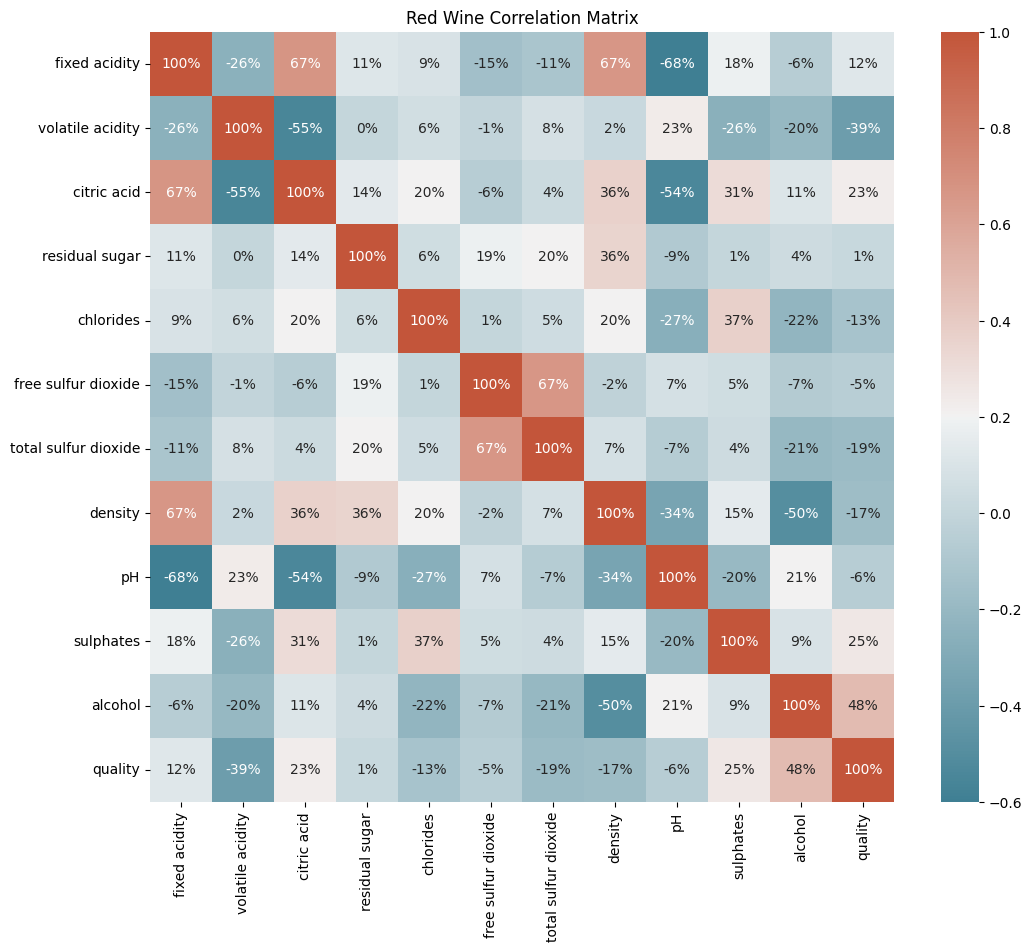

In [19]:
## After preprocessing 
correlation_matrix = red_wine_raw.corr()
percent_labels = correlation_matrix.multiply(100).round().astype(int).astype(str) + '%'
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=percent_labels, fmt='',
            cmap= sns.diverging_palette(220, 20, as_cmap=True), vmin=-0.6, vmax=1)
plt.title('Red Wine Correlation Matrix')
plt.show()


In [20]:
X = red_wine.drop('quality', axis=1)
y = red_wine['quality']

In [21]:
# Ranked table of correlations with quality sorted by percentage of correlation.
corr_pct = (X.corrwith(y) * 100).round().astype(int)
corr_ranked = corr_pct.reindex(corr_pct.abs().sort_values(ascending=False).index)

correlation_table = corr_ranked.rename_axis('Name').reset_index(name='Correlation')
correlation_table.insert(0, 'Rank', range(1, len(correlation_table) + 1))
correlation_table['Correlation'] = correlation_table['Correlation'].astype(str) + '%'

correlation_table.style.hide(axis='index')

Rank,Name,Correlation
1,alcohol,48%
2,volatile acidity,-40%
3,sulphates,25%
4,citric acid,23%
5,total sulfur dioxide,-18%
6,density,-18%
7,chlorides,-13%
8,fixed acidity,12%
9,pH,-6%
10,free sulfur dioxide,-5%


### Corelation Heatmap analysis and comparisons
- So from corelation table and the table from it is one to one exact how it is
- it was challenging in finding out how to do it and had to have help with claude in understanding of how the paper was saying how they encoded quality and the correlation heatmap is before encoding and had to try multiple times to get it exact. The procedure of following the paper is not in order and that is one of the challenges I am facing. 

- with dropping the duplicates and no values has influence on correlation with changing some correlations with 1% difference with the raw and preprocessed data frames. 
- this is also interesting even though the summary showed differences the correlation table is exact matching with what the paper got. 

### Bar Charts 
- Residual sugar vs quality
- Alcohol vs quality
Using the raw data as nothing has been noted on using the preprocessed data

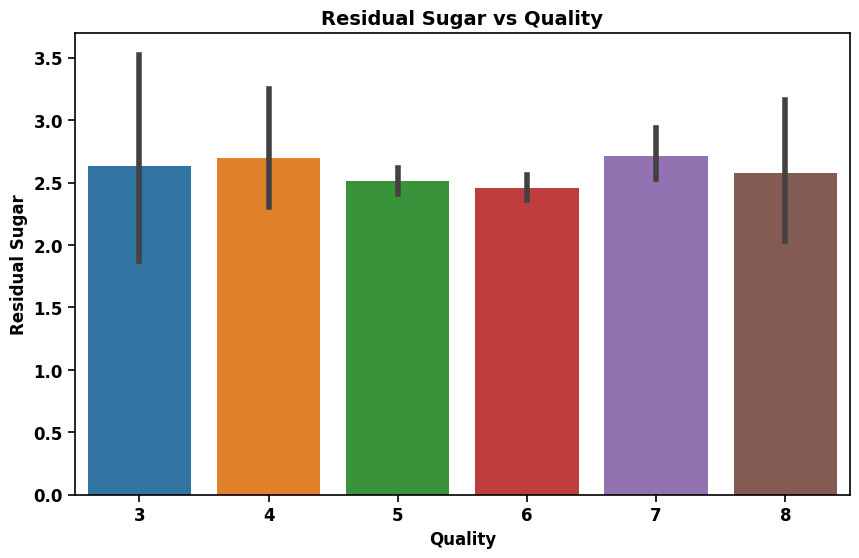

In [22]:
plt.figure(figsize=(10,6))
ax = sns.barplot(y='residual sugar', x='quality', data=red_wine, palette='tab10', err_kws={'linewidth': 4.0})
ax.grid(False)
ax.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
for spine in ax.spines.values(): spine.set_visible(True),spine.set_linewidth(1.2),spine.set_color('black')
ax.tick_params(axis='x', which='major', bottom=True, top=False, length=5, width=1.2, direction='out', color='black', labelcolor='black')
ax.tick_params(axis='y', which='major', left=True, right=False, length=5, width=1.2, direction='out', color='black', labelcolor='black')
plt.ylabel('Residual Sugar', fontsize=12, fontweight='bold')
plt.xlabel('Quality', fontsize=12, fontweight='bold')
plt.title('Residual Sugar vs Quality', fontsize=14, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.show()

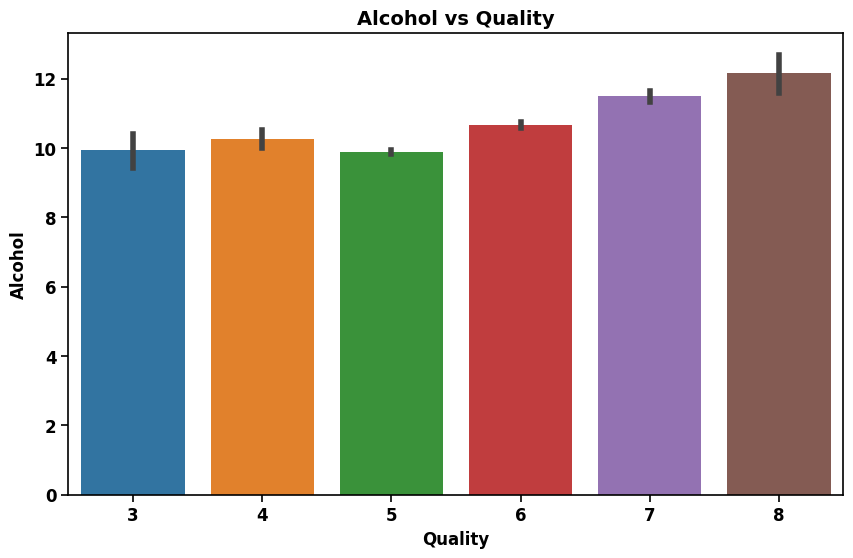

In [23]:
plt.figure(figsize=(10,6))
ax = sns.barplot(y='alcohol', x='quality', data=red_wine, palette='tab10', err_kws={'linewidth': 4.0})
ax.grid(False)
ax.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
for spine in ax.spines.values(): spine.set_visible(True),spine.set_linewidth(1.2),spine.set_color('black')
ax.tick_params(axis='x', which='major', bottom=True, top=False, length=5, width=1.2, direction='out', color='black', labelcolor='black')
ax.tick_params(axis='y', which='major', left=True, right=False, length=5, width=1.2, direction='out', color='black', labelcolor='black')
plt.ylabel('Alcohol', fontsize=12, fontweight='bold')
plt.xlabel('Quality', fontsize=12, fontweight='bold')
plt.title('Alcohol vs Quality', fontsize=14, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.show()

- The bar plots can be reproduced exactly as the paper shows, however I knew from the correlation index they are using the raw data not the preprocessed data. 
- This also shows why they dropped residual sugar with it having very very little correlation with quality across all the wines. 

### Unbalanced Data bar chart

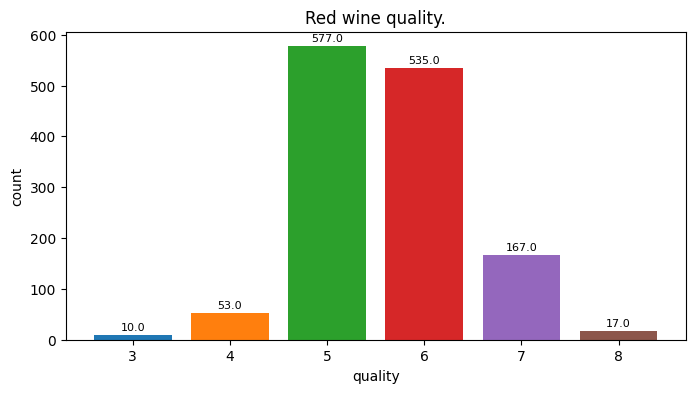

In [24]:
quality_counts = red_wine['quality'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=len(quality_counts))

plt.figure(figsize=(8, 4))
bars = plt.bar(quality_counts.index, quality_counts.values, color=colors)
plt.title('Red wine quality.')
plt.xlabel('quality')
plt.ylabel('count')
plt.grid(False)

for bar, count in zip(bars, quality_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, count + 5, f'{float(count):.1f}', ha='center', va='bottom', fontsize=8)

plt.show()

- This is the same exact graph shown in the paper in 5.1
- The data is skewed to the right however and there is hardly and low quality wine in the data
- There needs to be more data to prevent overfitting and more data on higher and low quality wine for better model results and metrics 

#### Dropping Residual Sugar 

In [25]:
# Rebuild processed data with encoded quality and without residual sugar.
red_wine_processed= red_wine.drop(columns=['residual sugar']).copy()
red_wine_processed['quality'] = red_wine_encoded

In [26]:
red_wine_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   chlorides             1359 non-null   float64
 4   free sulfur dioxide   1359 non-null   float64
 5   total sulfur dioxide  1359 non-null   float64
 6   density               1359 non-null   float64
 7   pH                    1359 non-null   float64
 8   sulphates             1359 non-null   float64
 9   alcohol               1359 non-null   float64
 10  quality               1359 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 127.4 KB


## Classification Methods
- With no code available and in the paper they explain it mathematically I am going to just use basic modeling but if given that they normalized the data 

### No train test split
- Before going in the paper there is not test train split noted and with no code as well to show that they did that I am going to to make my own test train split for the modeling which should have happened with labeling X and y, with doing a 80% training and 20% test sets. 
- To have a better modeling I am using the pre processed data with the label encoded quality and the duplicates and no value removed.

### Importing Libraries 
- unknown what libraries used in the paper added to do the modeling and evaluation to try to reproduce the results from the paper.

In [27]:
from sklearn.svm import LinearSVR, SVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_blobs
from sklearn.model_selection import cross_val_score, RepeatedKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score


## Test Train Split and Smote

In [28]:
# pip install imbalanced-learn had to install new libraries to do SMOTE
from imblearn.over_sampling import SMOTE

In [29]:
from sklearn.model_selection import train_test_split
y = red_wine_processed['quality']
X = red_wine_processed.drop(columns=['quality'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
# Apply SMOTE only for the hyperparameter-tuned model sections.
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

## Modeling
- for all the modeling I am just going to use the base model as much as I can and then get the hyperparameter after each one
- to make sure there is no confusion will have suffixes for each model on most of the variables and even the test train split will have alias for each model. 
- after all the modeling there will be 2 tables one with the base models showing accuracy, precision, recall, and the F1 statistic
- the best model will then be used to find the feature importance for that model

- The order of modeling will go by the order of the tables 
    - SVM or support vector machine
    - Random Forest or RF
    - K-Nearest Neighbor, or KNN
    - Gradient Boosting, or GB
    - Decision Tree, or DT


### Support Vector Machine

- without knowing the parameters given for even the base model 

In [32]:
# Base SVM uses the scaled train/test split without SMOTE.
X_train_svm, X_test_svm, y_train_svm, y_test_svm = X_train_scaled, X_test_scaled, y_train, y_test

In [33]:
svm_model = SVC()
svm_model.fit(X_train_svm, y_train_svm)
y_pred_svm = svm_model.predict(X_test_svm)
y_pred_svm

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2], dtype=int64)

In [34]:
svm_acc_train = svm_model.score(X_train_svm, y_train_svm)
svm_acc_test = svm_model.score(X_test_svm, y_test_svm)
print(f"SVM Accuracy on Training Set: {svm_acc_train:.4f}")
print(f"SVM Accuracy on Test Set: {svm_acc_test:.4f}")

SVM Accuracy on Training Set: 0.8510
SVM Accuracy on Test Set: 0.8419


In [35]:
# Weighted summary metrics for multiclass SVM.
svm_precision_weighted = precision_score(y_test_svm, y_pred_svm, average='weighted', zero_division=0)
svm_recall_weighted = recall_score(y_test_svm, y_pred_svm, average='weighted', zero_division=0)
svm_f1_weighted = f1_score(y_test_svm, y_pred_svm, average='weighted', zero_division=0)
print(f"SVM Precision (weighted): {svm_precision_weighted:.4f}")
print(f"SVM Recall (weighted): {svm_recall_weighted:.4f}")
print(f"SVM F1 Score (weighted): {svm_f1_weighted:.4f}")

SVM Precision (weighted): 0.7993
SVM Recall (weighted): 0.8419
SVM F1 Score (weighted): 0.7945


In [36]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1_vals, _ = precision_recall_fscore_support(
    y_test_svm, y_pred_svm, labels=[0, 1, 2], zero_division=0
)

class_metrics = {
    0: {'precision': prec[0], 'recall': rec[0], 'f1': f1_vals[0]},
    1: {'precision': prec[1], 'recall': rec[1], 'f1': f1_vals[1]},
    2: {'precision': prec[2], 'recall': rec[2], 'f1': f1_vals[2]},
}
class_metrics

{0: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
 1: {'precision': 0.842911877394636,
  'recall': 0.990990990990991,
  'f1': 0.9109730848861284},
 2: {'precision': 0.8181818181818182,
  'recall': 0.24324324324324326,
  'f1': 0.375}}

In [37]:
model_predictions = {'SVM': y_pred_svm}

print(f"SVM Accuracy: {svm_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics[cls]['precision']:.4f}, "
        f"Recall: {class_metrics[cls]['recall']:.4f}, "
        f"F1: {class_metrics[cls]['f1']:.4f}"
    )

SVM Accuracy: 0.8419
Class 0 -> Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Class 1 -> Precision: 0.8429, Recall: 0.9910, F1: 0.9110
Class 2 -> Precision: 0.8182, Recall: 0.2432, F1: 0.3750


- now making the table for the models to make it look just like the one in the paper, as close as possible, had to have help to get it look similar and used github copilot for this

In [38]:
from sklearn.metrics import classification_report, accuracy_score

def _coerce_to_class_labels(y_pred, class_labels):
    y_pred = np.asarray(y_pred)
    if np.issubdtype(y_pred.dtype, np.floating):
        label_array = np.asarray(class_labels, dtype=float)
        nearest_idx = np.abs(y_pred.reshape(-1, 1) - label_array.reshape(1, -1)).argmin(axis=1)
        return label_array[nearest_idx].astype(int)
    return y_pred

def _canonical_prediction_key(name):
    key = str(name).strip().lower()

    for prefix in ('y_pred_',):
        if key.startswith(prefix):
            key = key[len(prefix):]
            break

    for suffix in ('_y_pred',):
        if key.endswith(suffix):
            key = key[:-len(suffix)]
            break

    return key

def _resolve_prediction_dict(predictions_by_model):
    canonical_predictions = {}
    for pred_key, pred_values in predictions_by_model.items():
        canonical_predictions.setdefault(_canonical_prediction_key(pred_key), pred_values)
    return canonical_predictions

def _resolve_model_values(values_by_model):
    canonical_values = {}
    for value_key, value in values_by_model.items():
        canonical_values.setdefault(_canonical_prediction_key(value_key), value)
    return canonical_values

def build_model_comparison_table(y_true, predictions_by_model, model_order=None, class_labels=None, y_true_by_model=None):
    if model_order is None:
        model_order = list(predictions_by_model.keys())

    default_y_true = np.asarray(y_true)
    if class_labels is None:
        class_labels = sorted(np.unique(default_y_true))
    else:
        class_labels = list(class_labels)

    row_index = [str(c) for c in class_labels] + ['Accuracy']
    col_index = pd.MultiIndex.from_product(
        [model_order, ['Precision', 'Recall', 'F1 Score']],
        names=['Model', 'Metric']
    )

    table = pd.DataFrame(index=row_index, columns=col_index, dtype=float)

    canonical_predictions = _resolve_prediction_dict(predictions_by_model)
    canonical_y_true = _resolve_model_values(y_true_by_model or {})

    for model_name in model_order:
        y_pred = predictions_by_model.get(model_name)
        if y_pred is None:
            y_pred = canonical_predictions.get(_canonical_prediction_key(model_name))
        if y_pred is None:
            continue

        current_y_true = default_y_true
        if y_true_by_model is not None:
            current_y_true = y_true_by_model.get(model_name)
            if current_y_true is None:
                current_y_true = canonical_y_true.get(_canonical_prediction_key(model_name), default_y_true)
        current_y_true = np.asarray(current_y_true)

        y_pred = _coerce_to_class_labels(y_pred, class_labels)
        report = classification_report(current_y_true, y_pred, labels=class_labels, output_dict=True, zero_division=0)

        for cls in class_labels:
            cls_key = str(cls)
            table.loc[str(cls), (model_name, 'Precision')] = report.get(cls_key, {}).get('precision', np.nan)
            table.loc[str(cls), (model_name, 'Recall')] = report.get(cls_key, {}).get('recall', np.nan)
            table.loc[str(cls), (model_name, 'F1 Score')] = report.get(cls_key, {}).get('f1-score', np.nan)

        table.loc['Accuracy', (model_name, 'Precision')] = accuracy_score(current_y_true, y_pred)
        table.loc['Accuracy', (model_name, 'Recall')] = np.nan
        table.loc['Accuracy', (model_name, 'F1 Score')] = np.nan

    return table


model_order = ['SVM', 'RF', 'KNN', 'GB', 'DT']
y_test_by_model = {
    'SVM': globals().get('y_test_svm', y_test),
    'RF': globals().get('y_test_rf', y_test),
    'KNN': globals().get('y_test_knn', y_test),
    'GB': globals().get('y_test_gb', y_test),
    'DT': globals().get('y_test_dt', y_test),
}
comparison_table = build_model_comparison_table(
    y_test,
    model_predictions,
    model_order=model_order,
    class_labels=[0, 1, 2],
    y_true_by_model=y_test_by_model,
)

comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')

- Without knowing the parameters used for test-train-split, SMOTE, or for all models I will get as close as possible to the same values but for SVM I can not get close to what they are getting without getting the code they used which is not available. To keep this process simple I am just going to for now on use the basic model parameters for this table then another table when doing the hyper parameters 

#### SVM hyperparameter

In [39]:
# Alias scaled data with _svm suffix to keep SVM variables separate from other models
X_train_svm_optimal, X_test_svm_optimal, y_train_svm_optimal, y_test_svm_optimal = X_train_balanced, X_test_scaled, y_train_balanced, y_test

In [ ]:
# GridSearchCV with stratified folds for more stable multiclass tuning.
from sklearn.model_selection import StratifiedKFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted'
}
param_grid_svm = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 50, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 50, 100],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3],
        'gamma': ['scale', 0.01],
        'coef0': [0.0, 0.5],
        'class_weight': [None, 'balanced']
    }
]

grid_search_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=cv_strategy,
    scoring=scoring_metrics,
    refit='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_svm.fit(X_train_svm_optimal, y_train_svm_optimal)

svm_best_params = grid_search_svm.best_params_
svm_best_score = grid_search_svm.best_score_
svm_best_idx = grid_search_svm.best_index_
svm_best_acc = grid_search_svm.cv_results_['mean_test_accuracy'][svm_best_idx]
svm_best_prec = grid_search_svm.cv_results_['mean_test_precision_weighted'][svm_best_idx]
svm_best_rec = grid_search_svm.cv_results_['mean_test_recall_weighted'][svm_best_idx]

print(f"Best SVM Parameters: {svm_best_params}")
print(f"Best SVM CV Accuracy: {svm_best_acc:.4f}")
print(f"Best SVM CV Precision (weighted): {svm_best_prec:.4f}")
print(f"Best SVM CV Recall (weighted): {svm_best_rec:.4f}")
print(f"Best SVM CV F1 (weighted): {svm_best_score:.4f}")

Fitting 5 folds for each of 98 candidates, totalling 490 fits
Best SVM Parameters: {'C': 100, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV F1 (weighted): 0.9275


In [41]:
svm_model_optimal = grid_search_svm.best_estimator_
svm_model_optimal.fit(X_train_svm_optimal, y_train_svm_optimal)
y_pred_svm_optimal = svm_model_optimal.predict(X_test_svm_optimal)
y_pred_svm_optimal

array([1, 1, 1, 1, 1, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2,
       1, 1, 1, 0, 0, 1, 2, 1, 1, 2, 1, 1, 2, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 0, 2,
       1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 2, 1, 1, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       2, 1, 2, 2, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 1,
       1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 2, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       0, 0, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 2,
       0, 1, 1, 1, 1, 2, 1, 2], dtype=int64)

In [42]:
svm_optimal_acc_train = svm_model_optimal.score(X_train_svm_optimal, y_train_svm_optimal)
svm_optimal_acc_test = svm_model_optimal.score(X_test_svm_optimal, y_test_svm_optimal)
print(f"SVM Accuracy on Training Set: {svm_optimal_acc_train:.4f}")
print(f"SVM Accuracy on Test Set: {svm_optimal_acc_test:.4f}")

SVM Accuracy on Training Set: 0.9779
SVM Accuracy on Test Set: 0.7684


In [43]:
# Weighted summary metrics for multiclass SVM.
svm_optimal_precision_weighted = precision_score(y_test_svm_optimal, y_pred_svm_optimal, average='weighted', zero_division=0)
svm_optimal_recall_weighted = recall_score(y_test_svm_optimal, y_pred_svm_optimal, average='weighted', zero_division=0)
svm_optimal_f1_weighted = f1_score(y_test_svm_optimal, y_pred_svm_optimal, average='weighted', zero_division=0)
print(f"SVM Precision (weighted): {svm_optimal_precision_weighted:.4f}")
print(f"SVM Recall (weighted): {svm_optimal_recall_weighted:.4f}")
print(f"SVM F1 Score (weighted): {svm_optimal_f1_weighted:.4f}")

SVM Precision (weighted): 0.7998
SVM Recall (weighted): 0.7684
SVM F1 Score (weighted): 0.7821


In [44]:
prec_svm_optimal, rec_svm_optimal, f1_vals_svm_optimal, _ = precision_recall_fscore_support(
    y_test_svm_optimal, y_pred_svm_optimal, labels=[0, 1, 2], zero_division=0
)

class_metrics_svm_optimal = {
    0: {'precision': prec_svm_optimal[0], 'recall': rec_svm_optimal[0], 'f1': f1_vals_svm_optimal[0]},
    1: {'precision': prec_svm_optimal[1], 'recall': rec_svm_optimal[1], 'f1': f1_vals_svm_optimal[1]},
    2: {'precision': prec_svm_optimal[2], 'recall': rec_svm_optimal[2], 'f1': f1_vals_svm_optimal[2]},
}
class_metrics_svm_optimal

{0: {'precision': 0.18181818181818182,
  'recall': 0.3076923076923077,
  'f1': 0.22857142857142856},
 1: {'precision': 0.8840579710144928,
  'recall': 0.8243243243243243,
  'f1': 0.8531468531468531},
 2: {'precision': 0.5116279069767442,
  'recall': 0.5945945945945946,
  'f1': 0.55}}

In [45]:
print(f"SVM Accuracy: {svm_optimal_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_svm_optimal[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_svm_optimal[cls]['recall']:.4f}, "
        f"F1: {class_metrics_svm_optimal[cls]['f1']:.4f}"
    )

SVM Accuracy: 0.7684
Class 0 -> Precision: 0.1818, Recall: 0.3077, F1: 0.2286
Class 1 -> Precision: 0.8841, Recall: 0.8243, F1: 0.8531
Class 2 -> Precision: 0.5116, Recall: 0.5946, F1: 0.5500


In [46]:
optimized_predictions = {'SVM': y_pred_svm_optimal}

optimized_comparison_table = build_model_comparison_table(
    y_test,
    optimized_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2],
    y_true_by_model={'SVM': globals().get('y_test_svm_optimal', y_test)},
)
optimized_comparison_table.style.format('{:.2f}', na_rep='').set_caption('Optimized Model Comparison by Class')

### Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [48]:
# Base Random Forest uses the scaled train/test split without SMOTE.
X_train_rf, X_test_rf, y_train_rf, y_test_rf = X_train_scaled, X_test_scaled, y_train, y_test

In [49]:
random_forest_model = RandomForestClassifier()
random_forest_model.fit(X_train_rf, y_train_rf)
y_pred_rf = random_forest_model.predict(X_test_rf)
y_pred_rf

array([1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2], dtype=int64)

In [50]:
rf_acc_train = random_forest_model.score(X_train_rf, y_train_rf)
rf_acc_test = random_forest_model.score(X_test_rf, y_test_rf)
print(f"Random Forest Accuracy on Training Set: {rf_acc_train:.4f}")
print(f"Random Forest Accuracy on Test Set: {rf_acc_test:.4f}")

Random Forest Accuracy on Training Set: 1.0000
Random Forest Accuracy on Test Set: 0.8235


In [51]:
# Weighted summary metrics for multiclass Random Forest.
rf_precision_weighted = precision_score(y_test_rf, y_pred_rf, average='weighted', zero_division=0)
rf_recall_weighted = recall_score(y_test_rf, y_pred_rf, average='weighted', zero_division=0)
rf_f1_weighted = f1_score(y_test_rf, y_pred_rf, average='weighted', zero_division=0)
print(f"Random Forest Precision (weighted): {rf_precision_weighted:.4f}")
print(f"Random Forest Recall (weighted): {rf_recall_weighted:.4f}")
print(f"Random Forest F1 Score (weighted): {rf_f1_weighted:.4f}")

Random Forest Precision (weighted): 0.7700
Random Forest Recall (weighted): 0.8235
Random Forest F1 Score (weighted): 0.7929


In [52]:
prec_rf, rec_rf, f1_vals_rf, _ = precision_recall_fscore_support(y_test_rf, y_pred_rf, labels=[0, 1, 2], zero_division=0)

class_metrics_rf = {
    0: {'precision': prec_rf[0], 'recall': rec_rf[0], 'f1': f1_vals_rf[0]},
    1: {'precision': prec_rf[1], 'recall': rec_rf[1], 'f1': f1_vals_rf[1]},
    2: {'precision': prec_rf[2], 'recall': rec_rf[2], 'f1': f1_vals_rf[2]},
}
class_metrics_rf

{0: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
 1: {'precision': 0.8536585365853658,
  'recall': 0.9459459459459459,
  'f1': 0.8974358974358975},
 2: {'precision': 0.5384615384615384,
  'recall': 0.3783783783783784,
  'f1': 0.4444444444444444}}

In [53]:
model_predictions['RF'] = y_pred_rf  # Add RF to the predictions dict (keeps SVM)

print(f"RF Accuracy: {rf_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_rf[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_rf[cls]['recall']:.4f}, "
        f"F1: {class_metrics_rf[cls]['f1']:.4f}"
    )

RF Accuracy: 0.8235
Class 0 -> Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Class 1 -> Precision: 0.8537, Recall: 0.9459, F1: 0.8974
Class 2 -> Precision: 0.5385, Recall: 0.3784, F1: 0.4444


In [54]:
comparison_table = build_model_comparison_table(
    y_test,
    model_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2]
)

comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')

### Random Forest Hyperparameter

In [55]:
X_train_rf_optimal, X_test_rf_optimal, y_train_rf_optimal, y_test_rf_optimal = X_train_balanced, X_test_scaled, y_train_balanced, y_test

In [ ]:
# GridSearchCV to find the best hyperparameters for Random Forest
from sklearn.model_selection import StratifiedKFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted'
}
param_grid_rf = {
    'n_estimators': [300, 500],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 15, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced_subsample']
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=cv_strategy,
    scoring=scoring_metrics,
    refit='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train_rf_optimal, y_train_rf_optimal)

rf_best_params = grid_search_rf.best_params_
rf_best_score = grid_search_rf.best_score_
rf_best_idx = grid_search_rf.best_index_
rf_best_acc = grid_search_rf.cv_results_['mean_test_accuracy'][rf_best_idx]
rf_best_prec = grid_search_rf.cv_results_['mean_test_precision_weighted'][rf_best_idx]
rf_best_rec = grid_search_rf.cv_results_['mean_test_recall_weighted'][rf_best_idx]

print(f"Best Random Forest Parameters: {rf_best_params}")
print(f"Best Random Forest CV Accuracy: {rf_best_acc:.4f}")
print(f"Best Random Forest CV Precision (weighted): {rf_best_prec:.4f}")
print(f"Best Random Forest CV Recall (weighted): {rf_best_rec:.4f}")
print(f"Best Random Forest CV F1 (weighted): {rf_best_score:.4f}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best Random Forest Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best Random Forest CV F1 (weighted): 0.9279


In [57]:
random_forest_model_optimal = grid_search_rf.best_estimator_
y_pred_rf_optimal = random_forest_model_optimal.predict(X_test_rf_optimal)
y_pred_rf_optimal

array([1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 0, 1, 2, 1, 0, 1, 2,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 2], dtype=int64)

In [58]:
rf_optimal_acc_train = random_forest_model_optimal.score(X_train_rf_optimal, y_train_rf_optimal)
rf_optimal_acc_test = random_forest_model_optimal.score(X_test_rf_optimal, y_test_rf_optimal)
print(f"Random Forest Accuracy on Training Set: {rf_optimal_acc_train:.4f}")
print(f"Random Forest Accuracy on Test Set: {rf_optimal_acc_test:.4f}")

Random Forest Accuracy on Training Set: 1.0000
Random Forest Accuracy on Test Set: 0.8125


In [59]:
# Weighted summary metrics for multiclass Random Forest.
rf_optimal_precision_weighted = precision_score(y_test_rf_optimal, y_pred_rf_optimal, average='weighted', zero_division=0)
rf_optimal_recall_weighted = recall_score(y_test_rf_optimal, y_pred_rf_optimal, average='weighted', zero_division=0)
rf_optimal_f1_weighted = f1_score(y_test_rf_optimal, y_pred_rf_optimal, average='weighted', zero_division=0)
print(f"Random Forest Precision (weighted): {rf_optimal_precision_weighted:.4f}")
print(f"Random Forest Recall (weighted): {rf_optimal_recall_weighted:.4f}")
print(f"Random Forest F1 Score (weighted): {rf_optimal_f1_weighted:.4f}")

Random Forest Precision (weighted): 0.8191
Random Forest Recall (weighted): 0.8125
Random Forest F1 Score (weighted): 0.8130


In [60]:
prec_rf_optimal, rec_rf_optimal, f1_vals_rf_optimal, _ = precision_recall_fscore_support(y_test_rf_optimal, y_pred_rf_optimal, labels=[0, 1, 2], zero_division=0)

class_metrics_rf_optimal = {
    0: {'precision': prec_rf_optimal[0], 'recall': rec_rf_optimal[0], 'f1': f1_vals_rf_optimal[0]},
    1: {'precision': prec_rf_optimal[1], 'recall': rec_rf_optimal[1], 'f1': f1_vals_rf_optimal[1]},
    2: {'precision': prec_rf_optimal[2], 'recall': rec_rf_optimal[2], 'f1': f1_vals_rf_optimal[2]},
}
class_metrics_rf_optimal

{0: {'precision': 0.5714285714285714, 'recall': 0.3076923076923077, 'f1': 0.4},
 1: {'precision': 0.8904109589041096,
  'recall': 0.8783783783783784,
  'f1': 0.8843537414965986},
 2: {'precision': 0.4782608695652174,
  'recall': 0.5945945945945946,
  'f1': 0.5301204819277109}}

In [61]:
print(f"RF Accuracy: {rf_optimal_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_rf_optimal[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_rf_optimal[cls]['recall']:.4f}, "
        f"F1: {class_metrics_rf_optimal[cls]['f1']:.4f}"
    )

RF Accuracy: 0.8125
Class 0 -> Precision: 0.5714, Recall: 0.3077, F1: 0.4000
Class 1 -> Precision: 0.8904, Recall: 0.8784, F1: 0.8844
Class 2 -> Precision: 0.4783, Recall: 0.5946, F1: 0.5301


In [62]:
optimized_predictions = {'SVM': y_pred_svm_optimal, 'RF': y_pred_rf_optimal}

optimized_comparison_table = build_model_comparison_table(
    y_test,
    optimized_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2],
    y_true_by_model={
        'SVM': globals().get('y_test_svm_optimal', y_test),
        'RF': globals().get('y_test_rf_optimal', y_test),
        'KNN': globals().get('y_test_knn_optimal', y_test),
        'GB': globals().get('y_test_gb_optimal', y_test),
        'DT': globals().get('y_test_dt_optimal', y_test),
    },
)
optimized_comparison_table.style.format('{:.2f}', na_rep='').set_caption('Optimized Model Comparison by Class')

### K Nearest Neighbor 

In [63]:
# Base KNN uses the scaled train/test split without SMOTE.
X_train_knn, X_test_knn, y_train_knn, y_test_knn = X_train_scaled, X_test_scaled, y_train, y_test

In [64]:
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train_knn, y_train_knn)
y_pred_knn = KNN_model.predict(X_test_knn)
y_pred_knn

array([1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2], dtype=int64)

In [65]:
knn_acc_train = KNN_model.score(X_train_knn, y_train_knn)
knn_acc_test = KNN_model.score(X_test_knn, y_test_knn)
print(f"KNN Accuracy on Training Set: {knn_acc_train:.4f}")
print(f"KNN Accuracy on Test Set: {knn_acc_test:.4f}")

KNN Accuracy on Training Set: 0.8574
KNN Accuracy on Test Set: 0.8235


In [66]:
knn_precision_weighted = precision_score(y_test_knn, y_pred_knn, average='weighted', zero_division=0)
knn_recall_weighted = recall_score(y_test_knn, y_pred_knn, average='weighted', zero_division=0)
knn_f1_weighted = f1_score(y_test_knn, y_pred_knn, average='weighted', zero_division=0)
print(f"KNN Precision (weighted): {knn_precision_weighted:.4f}")
print(f"KNN Recall (weighted): {knn_recall_weighted:.4f}")
print(f"KNN F1 Score (weighted): {knn_f1_weighted:.4f}")

KNN Precision (weighted): 0.7830
KNN Recall (weighted): 0.8235
KNN F1 Score (weighted): 0.8020


In [67]:
prec_knn, rec_knn, f1_vals_knn, _ = precision_recall_fscore_support(y_test_knn, y_pred_knn, labels=[0, 1, 2], zero_division=0)
class_metrics_knn = {
    0: {'precision': prec_knn[0], 'recall': rec_knn[0], 'f1': f1_vals_knn[0]},
    1: {'precision': prec_knn[1], 'recall': rec_knn[1], 'f1': f1_vals_knn[1]},
    2: {'precision': prec_knn[2], 'recall': rec_knn[2], 'f1': f1_vals_knn[2]},
}
class_metrics_knn

{0: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
 1: {'precision': 0.865546218487395,
  'recall': 0.9279279279279279,
  'f1': 0.8956521739130435},
 2: {'precision': 0.5625,
  'recall': 0.4864864864864865,
  'f1': 0.5217391304347826}}

In [68]:
model_predictions['KNN'] = y_pred_knn  # Add KNN to the predictions dict (keeps SVM and RF)
print(f"KNN Accuracy: {knn_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_knn[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_knn[cls]['recall']:.4f}, "
        f"F1: {class_metrics_knn[cls]['f1']:.4f}"
    )

KNN Accuracy: 0.8235
Class 0 -> Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Class 1 -> Precision: 0.8655, Recall: 0.9279, F1: 0.8957
Class 2 -> Precision: 0.5625, Recall: 0.4865, F1: 0.5217


In [69]:
comparison_table = build_model_comparison_table(
    y_test,
    model_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2]
)

comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')


### KNN Hyperparameter

In [70]:
X_train_knn_optimal, X_test_knn_optimal, y_train_knn_optimal, y_test_knn_optimal = X_train_balanced, X_test_scaled, y_train_balanced, y_test

In [ ]:
# GridSearchCV to find the best hyperparameters for KNN
from sklearn.model_selection import StratifiedKFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted'
}
param_grid_knn = [
    {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
        'weights': ['uniform', 'distance'],
        'metric': ['minkowski'],
        'p': [1, 2, 3]
    }
]

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=cv_strategy,
    scoring=scoring_metrics,
    refit='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_knn.fit(X_train_knn_optimal, y_train_knn_optimal)

knn_best_params = grid_search_knn.best_params_
knn_best_score = grid_search_knn.best_score_
knn_best_idx = grid_search_knn.best_index_
knn_best_acc = grid_search_knn.cv_results_['mean_test_accuracy'][knn_best_idx]
knn_best_prec = grid_search_knn.cv_results_['mean_test_precision_weighted'][knn_best_idx]
knn_best_rec = grid_search_knn.cv_results_['mean_test_recall_weighted'][knn_best_idx]

print(f"Best KNN Parameters: {knn_best_params}")
print(f"Best KNN CV Accuracy: {knn_best_acc:.4f}")
print(f"Best KNN CV Precision (weighted): {knn_best_prec:.4f}")
print(f"Best KNN CV Recall (weighted): {knn_best_rec:.4f}")
print(f"Best KNN CV F1 (weighted): {knn_best_score:.4f}")

Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN CV F1 (weighted): 0.8752


In [72]:
KNN_model_optimal = grid_search_knn.best_estimator_
y_pred_knn_optimal = KNN_model_optimal.predict(X_test_knn_optimal)
y_pred_knn_optimal

array([0, 1, 1, 1, 2, 0, 2, 1, 2, 0, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 0, 1, 0, 1, 0, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2,
       1, 2, 1, 0, 1, 1, 2, 1, 1, 1, 1, 1, 2, 0, 2, 1, 1, 0, 2, 1, 1, 0,
       0, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 2, 1, 0, 2,
       2, 1, 2, 1, 1, 0, 0, 2, 2, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2,
       1, 1, 1, 1, 1, 2, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 0, 0, 1, 1,
       1, 2, 2, 1, 1, 2, 1, 1, 0, 1, 1, 2, 2, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       2, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1,
       1, 1, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2,
       1, 2, 1, 0, 0, 1, 0, 1, 0, 2, 1, 1, 1, 0, 1, 2, 1, 1, 2, 0, 2, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 0, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2,
       0, 1, 1, 1, 1, 2, 2, 1, 2, 2, 0, 2, 2, 0, 0, 1, 2, 1, 1, 0, 1, 2,
       0, 1, 2, 1, 1, 2, 2, 2], dtype=int64)

In [73]:
knn_acc_train_optimal = KNN_model_optimal.score(X_train_knn_optimal, y_train_knn_optimal)
knn_acc_test_optimal = KNN_model_optimal.score(X_test_knn_optimal, y_test_knn_optimal)
print(f"KNN Accuracy on Training Set: {knn_acc_train_optimal:.4f}")
print(f"KNN Accuracy on Test Set: {knn_acc_test_optimal:.4f}")

KNN Accuracy on Training Set: 1.0000
KNN Accuracy on Test Set: 0.6875


In [74]:
knn_precision_weighted_optimal = precision_score(y_test_knn_optimal, y_pred_knn_optimal, average='weighted', zero_division=0)
knn_recall_weighted_optimal = recall_score(y_test_knn_optimal, y_pred_knn_optimal, average='weighted', zero_division=0)
knn_f1_weighted_optimal = f1_score(y_test_knn_optimal, y_pred_knn_optimal, average='weighted', zero_division=0)
print(f"KNN Precision (weighted): {knn_precision_weighted_optimal:.4f}")
print(f"KNN Recall (weighted): {knn_recall_weighted_optimal:.4f}")
print(f"KNN F1 Score (weighted): {knn_f1_weighted_optimal:.4f}")

KNN Precision (weighted): 0.8244
KNN Recall (weighted): 0.6875
KNN F1 Score (weighted): 0.7246


In [75]:
prec_knn_optimal, rec_knn_optimal, f1_vals_knn_optimal, _ = precision_recall_fscore_support(y_test_knn_optimal, y_pred_knn_optimal, labels=[0, 1, 2], zero_division=0)
class_metrics_knn_optimal = {
    0: {'precision': prec_knn_optimal[0], 'recall': rec_knn_optimal[0], 'f1': f1_vals_knn_optimal[0]},
    1: {'precision': prec_knn_optimal[1], 'recall': rec_knn_optimal[1], 'f1': f1_vals_knn_optimal[1]},
    2: {'precision': prec_knn_optimal[2], 'recall': rec_knn_optimal[2], 'f1': f1_vals_knn_optimal[2]},
}
class_metrics_knn_optimal

{0: {'precision': 0.2, 'recall': 0.5384615384615384, 'f1': 0.2916666666666667},
 1: {'precision': 0.93125,
  'recall': 0.6711711711711712,
  'f1': 0.7801047120418848},
 2: {'precision': 0.4025974025974026,
  'recall': 0.8378378378378378,
  'f1': 0.543859649122807}}

In [76]:
print(f"KNN Accuracy: {knn_acc_test_optimal:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_knn_optimal[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_knn_optimal[cls]['recall']:.4f}, "
        f"F1: {class_metrics_knn_optimal[cls]['f1']:.4f}"
    )

KNN Accuracy: 0.6875
Class 0 -> Precision: 0.2000, Recall: 0.5385, F1: 0.2917
Class 1 -> Precision: 0.9313, Recall: 0.6712, F1: 0.7801
Class 2 -> Precision: 0.4026, Recall: 0.8378, F1: 0.5439


In [77]:
optimized_predictions = {'SVM': y_pred_svm_optimal, 'RF': y_pred_rf_optimal, 'KNN': y_pred_knn_optimal}

optimized_comparison_table = build_model_comparison_table(
    y_test,
    optimized_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2],
    y_true_by_model={
        'SVM': globals().get('y_test_svm_optimal', y_test),
        'RF': globals().get('y_test_rf_optimal', y_test),
        'KNN': globals().get('y_test_knn_optimal', y_test),
        'GB': globals().get('y_test_gb_optimal', y_test),
        'DT': globals().get('y_test_dt_optimal', y_test),
    },
)
optimized_comparison_table.style.format('{:.2f}', na_rep='').set_caption('Optimized Model Comparison by Class')

### Gradient Boosting 

In [78]:
# Base Gradient Boosting uses the scaled train/test split without SMOTE.
X_train_gb, X_test_gb, y_train_gb, y_test_gb = X_train_scaled, X_test_scaled, y_train, y_test

In [79]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train_gb, y_train_gb)
y_pred_gb = gb_model.predict(X_test_gb)
y_pred_gb


array([1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2], dtype=int64)

In [80]:
gb_acc_train = gb_model.score(X_train_gb, y_train_gb)
gb_acc_test = gb_model.score(X_test_gb, y_test_gb)
print(f"Gradient Boosting Accuracy on Training Set: {gb_acc_train:.4f}")
print(f"Gradient Boosting Accuracy on Test Set: {gb_acc_test:.4f}")


Gradient Boosting Accuracy on Training Set: 0.9604
Gradient Boosting Accuracy on Test Set: 0.8529


In [81]:
gb_precision_weighted = precision_score(y_test_gb, y_pred_gb, average='weighted', zero_division=0)
gb_recall_weighted = recall_score(y_test_gb, y_pred_gb, average='weighted', zero_division=0)
gb_f1_weighted = f1_score(y_test_gb, y_pred_gb, average='weighted', zero_division=0)
print(f"Gradient Boosting Precision (weighted): {gb_precision_weighted:.4f}")
print(f"Gradient Boosting Recall (weighted): {gb_recall_weighted:.4f}")
print(f"Gradient Boosting F1 Score (weighted): {gb_f1_weighted:.4f}")


Gradient Boosting Precision (weighted): 0.8057
Gradient Boosting Recall (weighted): 0.8529
Gradient Boosting F1 Score (weighted): 0.8270


In [82]:
prec_gb, rec_gb, f1_vals_gb, _ = precision_recall_fscore_support(y_test_gb, y_pred_gb, labels=[0, 1, 2], zero_division=0)
class_metrics_gb = {
    0: {'precision': prec_gb[0], 'recall': rec_gb[0], 'f1': f1_vals_gb[0]},
    1: {'precision': prec_gb[1], 'recall': rec_gb[1], 'f1': f1_vals_gb[1]},
    2: {'precision': prec_gb[2], 'recall': rec_gb[2], 'f1': f1_vals_gb[2]},
}
class_metrics_gb


{0: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
 1: {'precision': 0.8760330578512396,
  'recall': 0.954954954954955,
  'f1': 0.9137931034482759},
 2: {'precision': 0.6666666666666666,
  'recall': 0.5405405405405406,
  'f1': 0.5970149253731343}}

In [83]:
model_predictions['GB'] = y_pred_gb  # Add GB to the predictions dict (keeps SVM, RF, KNN)
print(f"GB Accuracy: {gb_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_gb[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_gb[cls]['recall']:.4f}, "
        f"F1: {class_metrics_gb[cls]['f1']:.4f}"
    )

GB Accuracy: 0.8529
Class 0 -> Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Class 1 -> Precision: 0.8760, Recall: 0.9550, F1: 0.9138
Class 2 -> Precision: 0.6667, Recall: 0.5405, F1: 0.5970


In [84]:
comparison_table = build_model_comparison_table(
    y_test,
    model_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2]
)
comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')

### Gradient Boosting Hyperparameter

In [85]:
X_train_gb_optimal, X_test_gb_optimal, y_train_gb_optimal, y_test_gb_optimal = X_train_balanced, X_test_scaled, y_train_balanced, y_test

In [ ]:
# GridSearchCV to find the best hyperparameters for Gradient Boosting
from sklearn.model_selection import StratifiedKFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted'
}
param_grid_gb = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
}
grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=cv_strategy,
    scoring=scoring_metrics,
    refit='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_gb.fit(X_train_gb_optimal, y_train_gb_optimal)
gb_best_params = grid_search_gb.best_params_
gb_best_score = grid_search_gb.best_score_
gb_best_idx = grid_search_gb.best_index_
gb_best_acc = grid_search_gb.cv_results_['mean_test_accuracy'][gb_best_idx]
gb_best_prec = grid_search_gb.cv_results_['mean_test_precision_weighted'][gb_best_idx]
gb_best_rec = grid_search_gb.cv_results_['mean_test_recall_weighted'][gb_best_idx]

print(f"Best Gradient Boosting Parameters: {gb_best_params}")
print(f"Best Gradient Boosting CV Accuracy: {gb_best_acc:.4f}")
print(f"Best Gradient Boosting CV Precision (weighted): {gb_best_prec:.4f}")
print(f"Best Gradient Boosting CV Recall (weighted): {gb_best_rec:.4f}")
print(f"Best Gradient Boosting CV F1 (weighted): {gb_best_score:.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


KeyboardInterrupt: 

In [ ]:
gb_model_optimal = grid_search_gb.best_estimator_
y_pred_gb_optimal = gb_model_optimal.predict(X_test_gb_optimal)
y_pred_gb_optimal

In [ ]:
gb_acc_train_optimal = gb_model_optimal.score(X_train_gb_optimal, y_train_gb_optimal)
gb_acc_test_optimal = gb_model_optimal.score(X_test_gb_optimal, y_test_gb_optimal)
print(f"Gradient Boosting Accuracy on Training Set: {gb_acc_train_optimal:.4f}")
print(f"Gradient Boosting Accuracy on Test Set: {gb_acc_test_optimal:.4f}")

In [ ]:
gb_precision_weighted_optimal = precision_score(y_test_gb_optimal, y_pred_gb_optimal, average='weighted', zero_division=0)
gb_recall_weighted_optimal = recall_score(y_test_gb_optimal, y_pred_gb_optimal, average='weighted', zero_division=0)
gb_f1_weighted_optimal = f1_score(y_test_gb_optimal, y_pred_gb_optimal, average='weighted', zero_division=0)
print(f"Gradient Boosting Precision (weighted): {gb_precision_weighted_optimal:.4f}")
print(f"Gradient Boosting Recall (weighted): {gb_recall_weighted_optimal:.4f}")
print(f"Gradient Boosting F1 Score (weighted): {gb_f1_weighted_optimal:.4f}")

In [ ]:
prec_gb_optimal, rec_gb_optimal, f1_vals_gb_optimal, _ = precision_recall_fscore_support(y_test_gb_optimal, y_pred_gb_optimal, labels=[0, 1, 2], zero_division=0)
class_metrics_gb_optimal = {
    0: {'precision': prec_gb_optimal[0], 'recall': rec_gb_optimal[0], 'f1': f1_vals_gb_optimal[0]},
    1: {'precision': prec_gb_optimal[1], 'recall': rec_gb_optimal[1], 'f1': f1_vals_gb_optimal[1]},
    2: {'precision': prec_gb_optimal[2], 'recall': rec_gb_optimal[2], 'f1': f1_vals_gb_optimal[2]},
}
class_metrics_gb_optimal

In [ ]:
print(f"GB Accuracy: {gb_acc_test_optimal:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_gb_optimal[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_gb_optimal[cls]['recall']:.4f}, "
        f"F1: {class_metrics_gb_optimal[cls]['f1']:.4f}"
    ) 

In [ ]:
optimized_predictions = {'SVM': y_pred_svm_optimal, 'RF': y_pred_rf_optimal, 'KNN': y_pred_knn_optimal, 'GB': y_pred_gb_optimal}

optimized_comparison_table = build_model_comparison_table(
    y_test,
    optimized_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2],
    y_true_by_model={
        'SVM': globals().get('y_test_svm_optimal', y_test),
        'RF': globals().get('y_test_rf_optimal', y_test),
        'KNN': globals().get('y_test_knn_optimal', y_test),
        'GB': globals().get('y_test_gb_optimal', y_test),
        'DT': globals().get('y_test_dt_optimal', y_test),
    },
)
optimized_comparison_table.style.format('{:.2f}', na_rep='').set_caption('Optimized Model Comparison by Class')

### Decision Tree

In [ ]:
# Base Decision Tree uses the scaled train/test split without SMOTE.
X_train_dt, X_test_dt, y_train_dt, y_test_dt = X_train_scaled, X_test_scaled, y_train, y_test

In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_dt, y_train_dt)
y_pred_dt = dt_model.predict(X_test_dt)
y_pred_dt

In [ ]:
dt_acc_train = dt_model.score(X_train_dt, y_train_dt)
dt_acc_test = dt_model.score(X_test_dt, y_test_dt)
print(f"Decision Tree Accuracy on Training Set: {dt_acc_train:.4f}")
print(f"Decision Tree Accuracy on Test Set: {dt_acc_test:.4f}")

In [ ]:
dt_precision_weighted = precision_score(y_test_dt, y_pred_dt, average='weighted', zero_division=0)
dt_recall_weighted = recall_score(y_test_dt, y_pred_dt, average='weighted', zero_division=0)
dt_f1_weighted = f1_score(y_test_dt, y_pred_dt, average='weighted', zero_division=0)
print(f"Decision Tree Precision (weighted): {dt_precision_weighted:.4f}")
print(f"Decision Tree Recall (weighted): {dt_recall_weighted:.4f}")
print(f"Decision Tree F1 Score (weighted): {dt_f1_weighted:.4f}")

In [ ]:
prec_dt, rec_dt, f1_vals_dt, _ = precision_recall_fscore_support(y_test_dt, y_pred_dt, labels=[0, 1, 2], zero_division=0)
class_metrics_dt = {
    0: {'precision': prec_dt[0], 'recall': rec_dt[0], 'f1': f1_vals_dt[0]},
    1: {'precision': prec_dt[1], 'recall': rec_dt[1], 'f1': f1_vals_dt[1]},
    2: {'precision': prec_dt[2], 'recall': rec_dt[2], 'f1': f1_vals_dt[2]},
}

In [ ]:
model_predictions['DT'] = y_pred_dt
print(f"DT Accuracy: {dt_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_dt[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_dt[cls]['recall']:.4f}, "
        f"F1: {class_metrics_dt[cls]['f1']:.4f}"
    )

In [ ]:
base_predictions = {'SVM': y_pred_svm, 'RF': y_pred_rf, 'KNN': y_pred_knn, 'GB': y_pred_gb, 'DT': y_pred_dt}
comparison_table = build_model_comparison_table(
    y_test,
    base_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2]
 )

comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')

### Decision Tree Hyperparameter

In [ ]:
X_train_dt_optimal, X_test_dt_optimal, y_train_dt_optimal, y_test_dt_optimal = X_train_balanced, X_test_scaled, y_train_balanced, y_test

In [ ]:
# GridSearchCV to find the best hyperparameters for Decision Tree
from sklearn.model_selection import StratifiedKFold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted'
}
param_grid_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 8, 16],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [None, 'sqrt'],
    'ccp_alpha': [0.0, 0.001, 0.005]
}
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv_strategy,
    scoring=scoring_metrics,
    refit='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_dt.fit(X_train_dt_optimal, y_train_dt_optimal)

dt_best_params = grid_search_dt.best_params_
dt_best_score = grid_search_dt.best_score_
dt_best_idx = grid_search_dt.best_index_
dt_best_acc = grid_search_dt.cv_results_['mean_test_accuracy'][dt_best_idx]
dt_best_prec = grid_search_dt.cv_results_['mean_test_precision_weighted'][dt_best_idx]
dt_best_rec = grid_search_dt.cv_results_['mean_test_recall_weighted'][dt_best_idx]
print(f"Best Decision Tree Parameters: {dt_best_params}")
print(f"Best Decision Tree CV Accuracy: {dt_best_acc:.4f}")
print(f"Best Decision Tree CV Precision (weighted): {dt_best_prec:.4f}")
print(f"Best Decision Tree CV Recall (weighted): {dt_best_rec:.4f}")
print(f"Best Decision Tree CV F1 (weighted): {dt_best_score:.4f}")

In [ ]:
dt_model_optimal = grid_search_dt.best_estimator_
y_pred_dt_optimal = dt_model_optimal.predict(X_test_dt_optimal)
y_pred_dt_optimal

In [ ]:
dt_acc_train_optimal = dt_model_optimal.score(X_train_dt_optimal, y_train_dt_optimal)
dt_acc_test_optimal = dt_model_optimal.score(X_test_dt_optimal, y_test_dt_optimal)
print(f"Decision Tree Accuracy on Training Set: {dt_acc_train_optimal:.4f}")
print(f"Decision Tree Accuracy on Test Set: {dt_acc_test_optimal:.4f}")

In [ ]:
dt_precision_weighted_optimal = precision_score(y_test_dt_optimal, y_pred_dt_optimal, average='weighted', zero_division=0)
dt_recall_weighted_optimal = recall_score(y_test_dt_optimal, y_pred_dt_optimal, average='weighted', zero_division=0)
dt_f1_weighted_optimal = f1_score(y_test_dt_optimal, y_pred_dt_optimal, average='weighted', zero_division=0)
print(f"Decision Tree Precision (weighted): {dt_precision_weighted_optimal:.4f}")
print(f"Decision Tree Recall (weighted): {dt_recall_weighted_optimal:.4f}")
print(f"Decision Tree F1 Score (weighted): {dt_f1_weighted_optimal:.4f}")

In [ ]:
prec_dt_optimal, rec_dt_optimal, f1_vals_dt_optimal, _ = precision_recall_fscore_support(y_test_dt_optimal, y_pred_dt_optimal, labels=[0, 1, 2], zero_division=0)
class_metrics_dt_optimal = {
    0: {'precision': prec_dt_optimal[0], 'recall': rec_dt_optimal[0], 'f1': f1_vals_dt_optimal[0]},
    1: {'precision': prec_dt_optimal[1], 'recall': rec_dt_optimal[1], 'f1': f1_vals_dt_optimal[1]},
    2: {'precision': prec_dt_optimal[2], 'recall': rec_dt_optimal[2], 'f1': f1_vals_dt_optimal[2]},
}
class_metrics_dt_optimal

In [ ]:
print(f"DT Accuracy: {dt_acc_test_optimal:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_dt_optimal[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_dt_optimal[cls]['recall']:.4f}, "
        f"F1: {class_metrics_dt_optimal[cls]['f1']:.4f}"
    )

In [ ]:
optimized_predictions = {'SVM': y_pred_svm_optimal, 'RF': y_pred_rf_optimal, 'KNN': y_pred_knn_optimal, 'GB': y_pred_gb_optimal, 'DT': y_pred_dt_optimal}
optimized_comparison_table = build_model_comparison_table(
    y_test,
    optimized_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2],
    y_true_by_model={
        'SVM': globals().get('y_test_svm_optimal', y_test),
        'RF': globals().get('y_test_rf_optimal', y_test),
        'KNN': globals().get('y_test_knn_optimal', y_test),
        'GB': globals().get('y_test_gb_optimal', y_test),
        'DT': globals().get('y_test_dt_optimal', y_test),
    },
)
optimized_comparison_table.style.format('{:.2f}', na_rep='').set_caption('Optimized Model Comparison by Class')

### Confusion Matrices


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix_single(y_true, y_pred, model_name='Model', class_labels=None, title_prefix='Confusion Matrix'):
    y_true = np.asarray(y_true)
    if class_labels is None:
        class_labels = sorted(np.unique(y_true))
    else:
        class_labels = list(class_labels)

    y_pred = _coerce_to_class_labels(y_pred, class_labels)
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(ax=ax, colorbar=False)
    ax.set_title(f'{title_prefix}: {model_name}')
    plt.tight_layout()
    plt.show()

In [ ]:
plot_confusion_matrix_single(y_test_svm, y_pred_svm, model_name='SVM', class_labels=[0, 1, 2])
plot_confusion_matrix_single(
    globals().get('y_test_svm_optimal', y_test_svm),
    y_pred_svm_optimal,
    model_name='SVM Optimized',
    class_labels=[0, 1, 2],
)

In [ ]:
plot_confusion_matrix_single(y_test_rf, y_pred_rf, model_name='Random Forest', class_labels=[0, 1, 2])
plot_confusion_matrix_single(
    globals().get('y_test_rf_optimal', y_test_rf),
    y_pred_rf_optimal,
    model_name='Random Forest Optimized',
    class_labels=[0, 1, 2],
)

In [ ]:
plot_confusion_matrix_single(y_test_knn, y_pred_knn, model_name='KNN', class_labels=[0, 1, 2])
plot_confusion_matrix_single(
    globals().get('y_test_knn_optimal', y_test_knn),
    y_pred_knn_optimal,
    model_name='KNN Optimized',
    class_labels=[0, 1, 2],
)

In [ ]:
plot_confusion_matrix_single(y_test_gb, y_pred_gb, model_name='GB', class_labels=[0, 1, 2])
plot_confusion_matrix_single(
    globals().get('y_test_gb_optimal', y_test_gb),
    y_pred_gb_optimal,
    model_name='GB Optimized',
    class_labels=[0, 1, 2],
)

In [ ]:
plot_confusion_matrix_single(y_test_dt, y_pred_dt, model_name='DT', class_labels=[0, 1, 2])
plot_confusion_matrix_single(
    globals().get('y_test_dt_optimal', y_test_dt),
    y_pred_dt_optimal,
    model_name='DT Optimized',
    class_labels=[0, 1, 2],
)

## Comparison Table for base and Optimized 

In [ ]:
comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')

In [ ]:
optimized_comparison_table.style.format('{:.2f}', na_rep='').set_caption('Optimized Model Comparison by Class')

In [ ]:
display(y_train.value_counts()) 
display(y_test.value_counts())
display(y_train_balanced.value_counts())

- comparing to the paper it is close but still not what the paper models are showing 
- without knowing certain things that should have been included with the paper or even just give the code with the paper as well
- The data could have been updated since then with not knowing exactly code by code how they the modeling, it is almost impossible to get the parameters just right to get the same conclusion as the paper has and the same statistics the models give.
- For the paper there best model was the SVM it came in third for what I tried to replicate with Random Forest and Gradient Boosting getting better accuracy and some better metrics than svm. The worst model for the data is K-Nearest Neighbor and Decision Tree. 
- There is a odd thing about the results of the paper with the quality of 0(bad wine) having such a high precision score for svm in the table how? when there is only 13 values for it in the y_test data and only 50 in the y_train data, even getting a 0.02 on recall it seem mathematically weird. Then for the so called "balanced" dataset having 890 for training is good but still only having 13 for testing is just bad data. It just doesn't make sense how they got such high percentages for class 0 in the balanced dataset if using y_test in anything.

## Feature Importance from best model performance Random Forest Optimized

In [ ]:
feature_names = X.columns.tolist()
best_model_name = 'RF'
best_model_score = rf_acc_test
best_model = random_forest_model

importance_df = pd.DataFrame({'Feature': feature_names,'Importance': best_model.feature_importances_}).sort_values('Importance', ascending=True)
figure = plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
sns.barplot(data=importance_df,y='Feature',x='Importance',orient='h',color='royalblue',edgecolor='white')
plt.title(f'Feature Importance for Random Forest', fontsize=14)
plt.show()

In [ ]:
feature_names = X.columns.tolist()
best_model_name = 'GB'
best_model_score = gb_acc_test
best_model = gb_model

importance_df = pd.DataFrame({'Feature': feature_names,'Importance': best_model.feature_importances_}).sort_values('Importance', ascending=True)
figure = plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
sns.barplot(data=importance_df,y='Feature',x='Importance',orient='h',color='royalblue',edgecolor='white')
plt.title(f'Feature Importance for Gradient Boosting', fontsize=14)
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

feature_names = X.columns.tolist()
best_model_name = 'SVM'
best_model_score = svm_acc_test
best_model = svm_model

perm = permutation_importance(best_model, X_test_svm, y_test_svm, n_repeats=20, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm.importances_mean}).sort_values('Importance', ascending=True)

figure = plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
sns.barplot(data=importance_df, y='Feature', x='Importance', orient='h', color='royalblue', edgecolor='white')
plt.title('Permutation Importance for Support Vector Machine', fontsize=14)
plt.show()

- Amazingly I got the feature importance almost spot on with only fixed acidity, citric acid, sulphates and voltile acidity flipped an but it stays in the same values as the feature importance on the paper. This is kind of surprising since their best model was SVM and random forest gets it almost the same with my code. 
- For both models and the feature importance for the SVM in the paper the top three are alcohol, volatile acidity, and sulphates but they are not in the same oder 